In [1]:
import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

from pyproj import Proj, Geod
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

crs = 'epsg:32610'

P = Proj(crs)
G = Geod(ellps='WGS84')

In [2]:
# Parkfield lat/lon → convert to your CRS
Px, Py = P(-120.441, 35.899)

gnss = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/cwu.final_nam14.vel',skiprows=35,sep='\s+')

# RTK AA
f = '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayVelocities_SingleLTandST_NEW.csv'
aartk = pd.read_csv(f,comment='#')
aartk.replace(-9999, np.nan, inplace=True)
aartk['easting'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[0]
aartk['northing'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[1]
aartk["dist_from_parkfield_m"] = np.sqrt(
    (aartk.easting - Px)**2 +
    (aartk.northing - Py)**2
)

sarE = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/East_defo_cm_yr_epsg32610.tif',masked=True)
sarN = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr_epsg32610.tif',masked=True)
lidE = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/EW_velocity_merged1m.tif',masked=True)
lidN = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/NS_velocity_merged1m.tif',masked=True)

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_90363/492197985.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  gnss = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/cwu.final_nam14.vel',skiprows=35,sep='\s+')


In [3]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

aas = np.unique(aartk['Name'])
aas = aas[aas != 'Topo Creek']

center_points = gpd.GeoDataFrame({
    'geometry': [None]*len(aas),
    'fault_azimuth': np.zeros(len(aas)),
    'Name': aas
}, crs=crs)

for i, naa in enumerate(aas):
    subset = aartk[aartk['Name'] == naa]
    
    x_mean = subset['easting'].mean()
    y_mean = subset['northing'].mean()
    
    center_points.loc[i, 'geometry'] = Point(x_mean, y_mean)
    center_points.loc[i, 'fault_azimuth'] = subset['Fault Azimuth'].mean()


## Define Profiles

In [4]:
# CHANGE THESE EVERY TIME YOU WANT TO CHANGE YOUR PROFILES
fault_map_path = '/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/FinalFaultGeomFiles/SimplerFaultTrace.geojson'
save = False

profile_length = 50*1000 # in meters, not pixels
pixel_res = 200 # Most WV
profile_width = 1000 # In meters 
profile_spacing = 10000 #in meters 
folder = '/Users/chanagan/Downloads/'
prefix = 'SARProfiles'

In [5]:
#swaths, swath_strikes, profiles, center_points, strikes, n_profs, azimuths = tt.generateProfiles(fault_map_path,profile_length,profile_width,profile_spacing,save=save,prefix=prefix,folder=folder)
#print(len(swaths),'Profiles')

## Decomposed SAR

Xu et al., 2021

In [43]:
gdalwarp -t_srs EPSG:32610 -te 630402.1 3964524.5 741690.6 4078192.7 -srcnodata -9999 -dstnodata -9999 -overwrite -of GTiff -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr.tif \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr_epsg32610.tif

SyntaxError: invalid syntax (3537640285.py, line 1)

In [6]:
data_type = 'SAR'
sarE = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/East_defo_cm_yr_epsg32610.tif',masked=True)
sarN = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr_epsg32610.tif',masked=True)

In [7]:
center_points

,geometry,fault_azimuth,Name
0,POINT (718689.068 3988285.242),-33.53,Bagby Ranch
1,POINT (688306.705 4021207.366),-42.95,DeAlvarez Ranch
2,POINT (732614.534 3974180.138),-40.29,Durham Ranch
3,POINT (701557.725 4006309.693),-30.65,Mee Ranch
4,POINT (697961.343 4010105.603),-38.91,Monarch Peak
5,POINT (647527.091 4065416.401),-51.64,Paicines Ranch
6,POINT (707635.628 4000071.701),-41.93,Peachtree Valley
7,POINT (666888.698 4045964.437),-43.28,Pinnacles
8,POINT (713545.47 3993697.767),-42.19,Slack Canyon
9,POINT (681860.516 4028496.154),-38.13,Smith Ranch


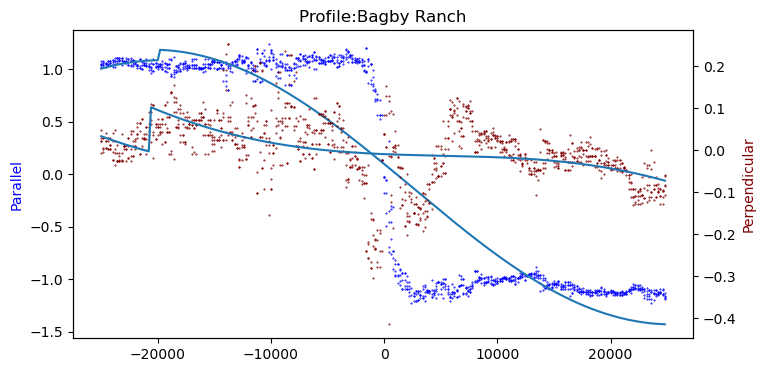

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile0_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


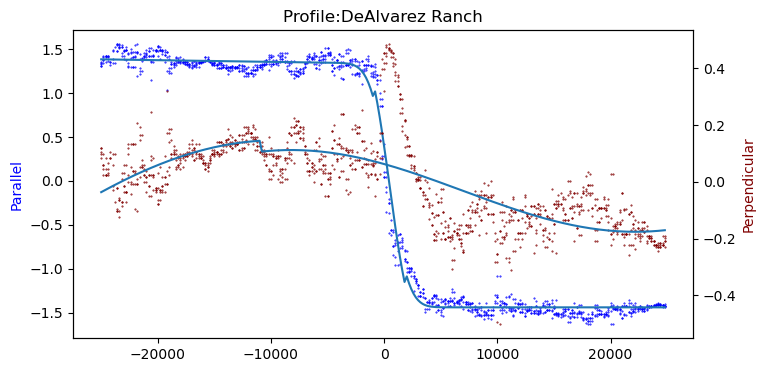

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile1_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


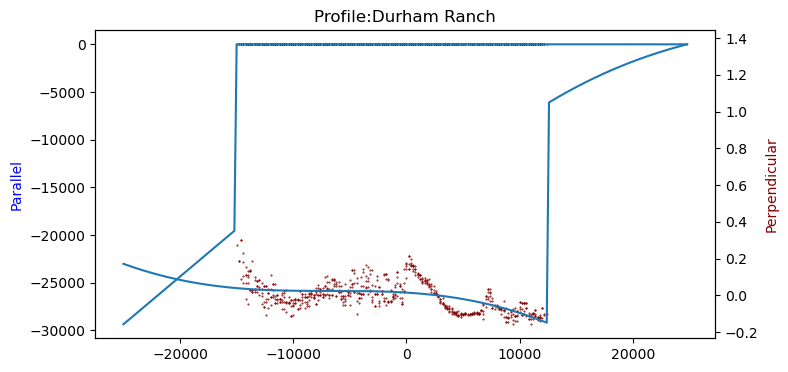

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile2_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


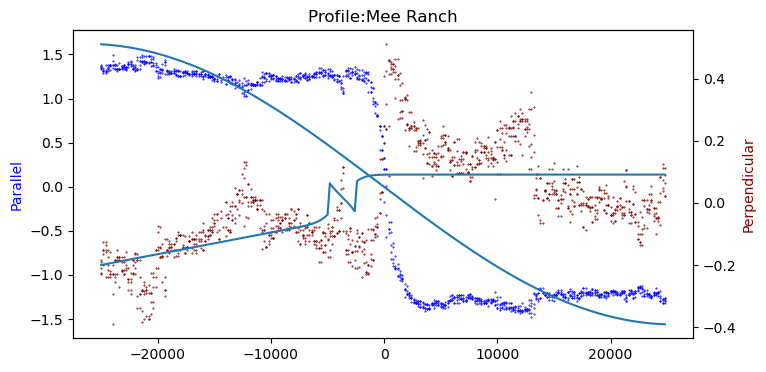

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile3_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


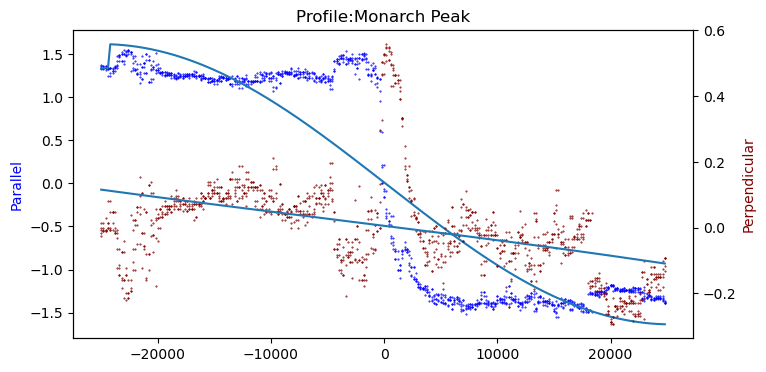

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile4_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


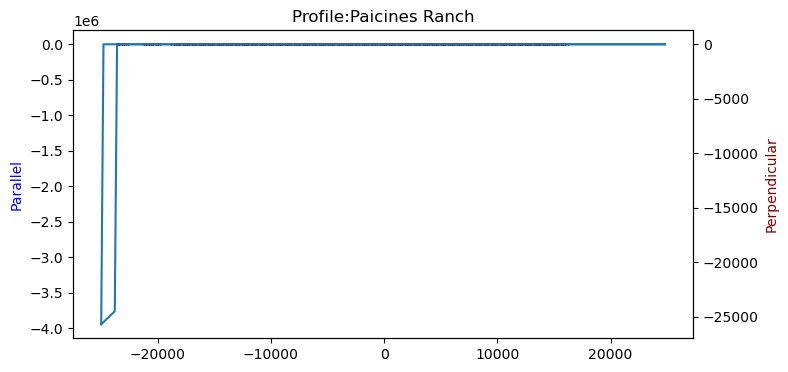

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile5_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


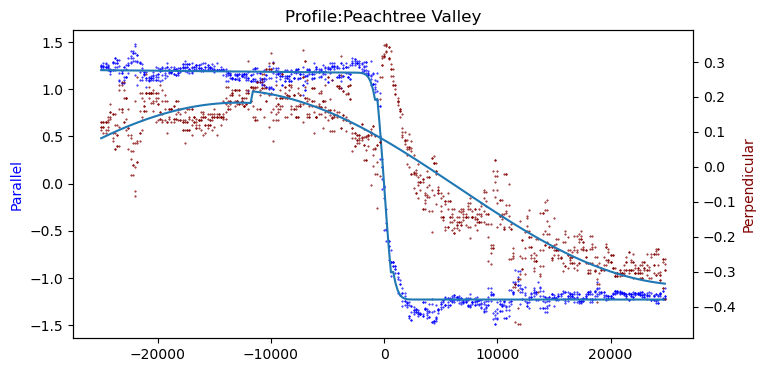

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile6_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


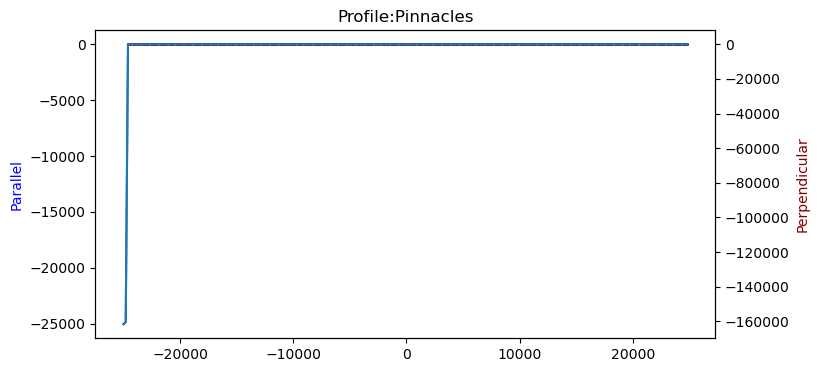

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile7_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


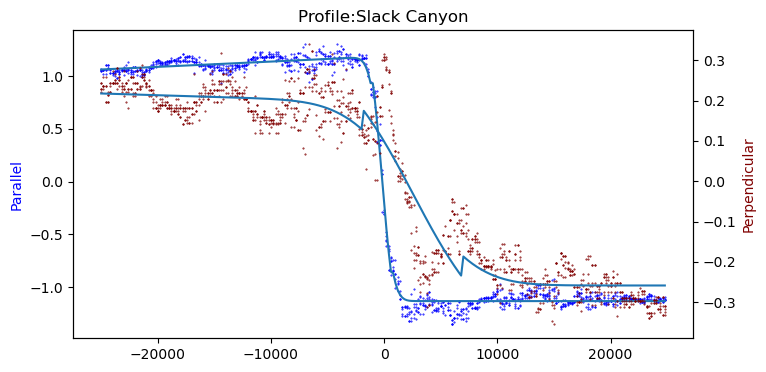

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile8_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


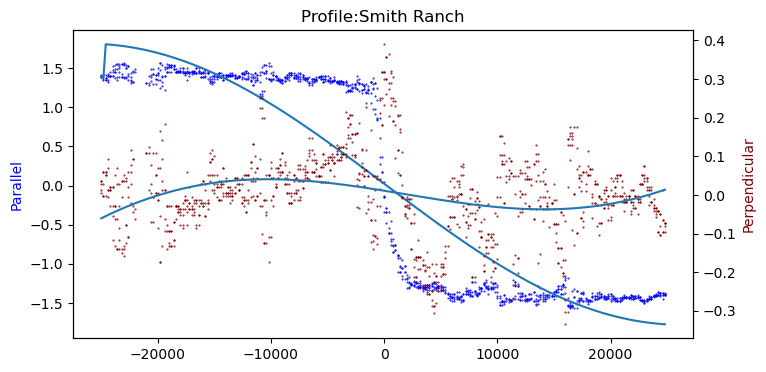

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile9_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


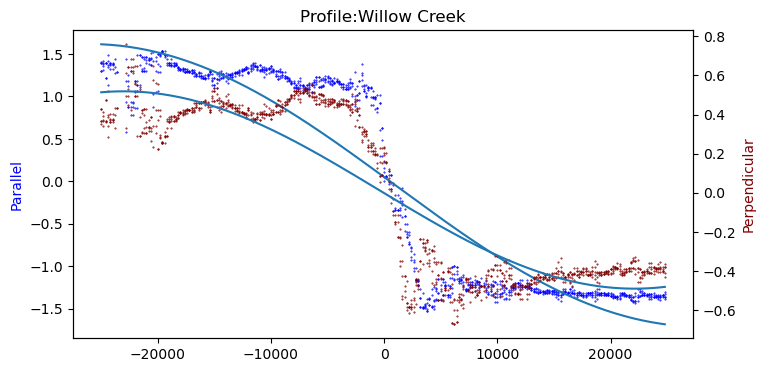

Saving profile fits to: /Users/chanagan/Downloads/SARProfiles_Profile10_SampleSpacing200_ProfLen50000_SwathWidth1000_SAR.csv


In [8]:
# loop through center points along fault 
# each profile has one defined center
points = center_points
ns = sarN
ew = sarE
plot = True
for i in np.arange(0, len(points)):
    ns_samps, pts, dists = tt.sample_swath(ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res,crs=crs)
    ns_samps[ns_samps == -9999] = np.nan

    ew_samps, pts, dists = tt.sample_swath(ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res,crs=crs)
    ew_samps[ew_samps == -9999] = np.nan

    par, perp = tt.projectParPerp(
        ns_samps - np.nanmean(ns_samps),
        ew_samps - np.nanmean(ew_samps),
        points.fault_azimuth.iloc[i]
    )

    par_intercept, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, par_slope1, par_slope1_sig, par_slope2, par_slope2_sig = tt.erf_curve_fit_twoslope(par, dists)
    perp_intercept, perp_total_offset, perp_fault_loc, perp_shear_width, perp_total_offset_sig, perp_fault_loc_sig, perp_shear_width_sig, perp_slope1, perp_slope1_sig, perp_slope2, perp_slope2_sig = tt.erf_curve_fit_twoslope(perp, dists)

    if plot is True:
        plt.figure(figsize=(8,4))
        plt.title('Profile:'+points.Name.iloc[i])
        plt.scatter(dists,par,s=0.2,color='blue')
        plt.plot(dists,tt.erf_function_twoslope(dists,par_intercept,par_total_offset, par_fault_loc, par_shear_width, par_slope1, par_slope2))
        plt.ylabel('Parallel',color='blue')
        plt.twinx()
        plt.scatter(dists,perp,s=0.2,color='maroon')
        plt.plot(dists,tt.erf_function_twoslope(dists,perp_intercept,perp_total_offset, perp_fault_loc, perp_shear_width, perp_slope1, perp_slope2))
        plt.ylabel('Perpendicular',color='maroon')
        plt.xlabel('Profile Distance')
        plt.show()

    fname = f'{folder}{prefix}_Profile{i}_SampleSpacing{pixel_res}_ProfLen{profile_length}_SwathWidth{profile_width}_{data_type}.csv'
    print(f'Saving profile fits to: {fname}')
    tdf = pd.DataFrame({'Northing':pts[:,1],
                    'Easting':pts[:,0],
                    'Profile Distance':dists,
                    'dN':ns_samps.flatten(), 
                     'dE':ew_samps.flatten(), 
                     f'dPar toward {round(points.fault_azimuth.iloc[i])}':par.flatten(), 
                     f'dPerp toward{round(points.fault_azimuth.iloc[i]+90)}':perp.flatten()})

    #tdf.to_csv(fname,float_format='%.4f',index=False)

Endpoint diff: 1.9399999999973767
Max diff: 2.127580669345888
Shear width diff: 5.30327065467213


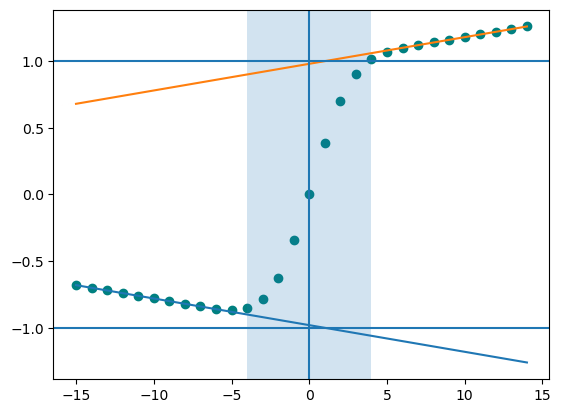

In [118]:
x = np.arange(-15,15)
offset = 2
width = 2
center, intercept = 0, 0
m1 = -offset/100
m2 = offset/100
y1 = tt.erf_function_twoslope(x, intercept, offset, center, width, m1, m2) # a b c ws m1 m2
y2 = tt.fit_arctan_independent_slopes(x, offset/3, width/3, center, m1, m2, intercept) # b ws c m1 m2 a
plt.scatter(x,y1,color='teal')
plt.plot(x,m1*(x-center-width/2)-offset/2)
plt.plot(x,m2*(x-center-width/2)+offset/2)
#plt.scatter(x,y2,color='black')
plt.axhline(-1*offset/2)
plt.axhline(offset/2)
plt.axvspan(-width*2,width*2,alpha=0.2)
plt.axvline(0)
print('Endpoint diff:', y1[-1]-y1[0])
print('Max diff:',y1.max()-y1.min())
print('Shear width diff:',tt.fit_arctan_independent_slopes(width, offset, width, center, m1, m2, intercept) - tt.fit_arctan_independent_slopes(-width, offset, width, center, m1, m2, intercept))

In [17]:
((x > c - ws) & (x <= c + ws))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True, False, False, False,
       False, False])

In [126]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit

def erf_function_twoslope(x, a1, a2, b, c, ws, m1, m2):
    """
    Two-slope erf with linear far fields.
    
    a1: intercept for left far-field
    a2: intercept for right far-field
    b: total offset (jump across the fault)
    c: fault location
    ws: shear width (controls transition)
    m1: slope in right far-field
    m2: slope in left far-field
    """ 
    # Smooth step function (0 -> 1 across fault)
    s = 0.5 * (1 + erf((x - c)/(ws * np.sqrt(2))))
    
    # Left side: linear slope + offset
    left_linear = a1 + m2*(x - c)
    
    # Right side: linear slope + offset
    right_linear = a2 + m1*(x - c)
    
    # Blend them with the smooth step and add the erf “jump”
    return left_linear*(1 - s) + right_linear*s + (b/2) * erf((x - c)/(ws * np.sqrt(2)))


def erf_curve_fit_twoslope(samps, dists, bounds=None):
    if bounds is None:
        bounds = ((-np.inf,-np.inf,np.nanmin(samps)*10,dists.min(),0,-np.inf,-np.inf),
                  (np.inf,np.inf,np.nanmax(samps)*10,dists.max(),2*dists.max(),np.inf,np.inf))
    try:
        popt, pcov = curve_fit(erf_function_twoslope,
                               dists[~np.isnan(samps)], samps[~np.isnan(samps)],
                               maxfev=10000, bounds=bounds)
        a1, a2, total_offset, fault_loc, shear_width, slope1, slope2 = popt
        total_offset_sig = np.sqrt(pcov[2, 2])
        fault_loc_sig = np.sqrt(pcov[3, 3])
        shear_width_sig = np.sqrt(pcov[4, 4])
        slope1_sig = np.sqrt(pcov[5, 5])
        slope2_sig = np.sqrt(pcov[6, 6])
    except:
        print('Fit failed.')
        return (np.nan,) * 12
    return (a1, a2, total_offset, fault_loc, shear_width, total_offset_sig,
            fault_loc_sig, shear_width_sig, slope1, slope1_sig, slope2, slope2_sig)

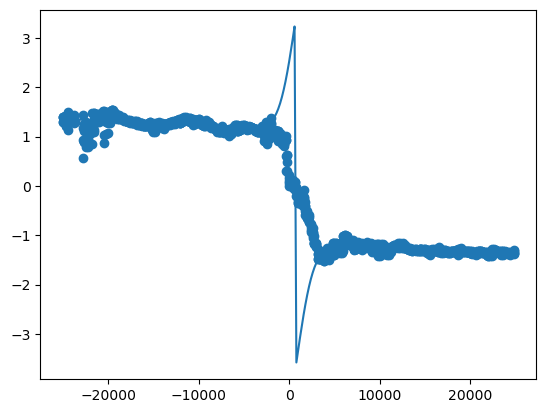

In [127]:
mult = 1
bounds = ((-np.inf,np.nanmin(par)*10,dists.min(),0,-1*mult,-1*mult),(np.inf,np.nanmax(par)*10,dists.max(),2*dists.max(),1*mult,1*mult))
par_intercept1, par_intercept2, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, slope1, slope1_sig, slope2, slope_2sig = erf_curve_fit_twoslope(par, dists, bounds=None)
plt.plot(dists,tt.erf_function_twoslope(dists,par_intercept1,par_intercept2,par_total_offset, par_fault_loc, par_shear_width,slope1,slope2))
plt.scatter(dists,par)